# **Neural Decoding of Decision Making Behavior**

This notebook analyzes neural population activity recorded during a decision making task. Using spike data and behavioral trial information, we test whether neural firing patterns can predict behavioral choice. The analysis includes **data preprocessing**, **exploratory visualization**, **dimensionality reduction using PCA**, **logistic regression decoding**, and a **permutation test for statistical significance**.

## **Project Question**

Can population neural activity predict behavioral choice, and what does this suggest about how neural populations encode decision relevant information?

## **Dataset Description**

This project uses processed data derived from the **International Brain Laboratory Brain Wide Map dataset**. The analysis combines three data modalities:

- **Spike level neural activity** in `spikes.csv`
- **Trial level behavioral variables** in `trials.csv`
- **Neuron metadata** in `neurons.csv`

These tables allow us to connect **neural activity**, **behavior**, and **anatomical metadata** within a single decoding pipeline.

In [1]:
#Loading data values
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression


## 1. Data Wrangling

In this section we load neural spike data, trial information, and neuron metadata. The dataset includes spike times associated with neurons and trials, behavioral variables such as stimulus condition and choice, and anatomical brain region labels for each neuron.

The goal of preprocessing is to convert spike timing data into firing rates for each neuron during each trial. These firing rates are then organized into a population activity matrix where rows represent trials and columns represent neurons. This matrix serves as the input for downstream dimensionality reduction and decoding analyses.

In [2]:
#Print Shapes
spikes = pd.read_csv("../data/spikes.csv")
trials = pd.read_csv("../data/trials.csv")
neurons = pd.read_csv("../data/neurons.csv")

print("Spikes shape:", spikes.shape)
print("Trials shape:", trials.shape)
print("Neurons shape:", neurons.shape)

Spikes shape: (61476908, 3)
Trials shape: (569, 4)
Neurons shape: (1557, 2)


In [3]:
#Missing values check
print(spikes.isnull().sum())
print(trials.isnull().sum())
print(neurons.isnull().sum())

trial_id      0
neuron_id     0
spike_time    0
dtype: int64
trial_id         0
choice           0
stimulus         0
response_time    0
dtype: int64
neuron_id       0
brain_region    0
dtype: int64


The dataset contains observations across multiple trials and neurons. We verify that no missing values are present in the dataset before proceeding with analysis. Handling missing data is an important preprocessing step because incomplete observations can bias downstream analyses.

In [4]:
#Creating population matrix
population_matrix = spikes.groupby(["trial_id","neuron_id"]).size().unstack(fill_value=0)

population_matrix.head()

neuron_id,0,1,2,3,4,5,6,7,8,9,...,1547,1548,1549,1550,1551,1552,1553,1554,1555,1556
trial_id,,,,,,,,,,,,,,,,,,,,,
0,2,4,0,0,17,0,10,50,1,79,...,0,0,0,0,0,0,4,0,0,0
1,0,6,0,0,9,6,5,48,3,131,...,0,0,0,0,0,0,0,0,0,0
2,0,10,0,0,21,1,5,29,0,115,...,0,0,0,0,0,0,0,0,0,0
3,0,10,0,0,26,1,1,32,0,150,...,0,0,0,0,0,0,0,0,0,0
4,0,9,0,0,28,2,3,29,1,180,...,0,0,0,0,0,0,0,0,0,0


The population activity matrix represents neural firing rates for each neuron during each trial. Rows correspond to trials and columns correspond to neurons. Each value represents the number of spikes recorded for a given neuron during a given trial.

## 2. Behavioral Data Visualization

We next visualize the behavioral trial variables used in the decoding analysis. These plots help characterize the trial labels and the behavioral structure of the dataset.

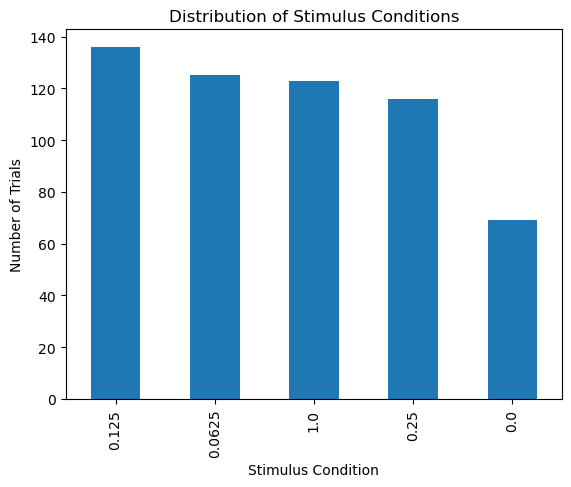

In [5]:
trials["stimulus"].value_counts().plot(kind="bar")

plt.xlabel("Stimulus Condition")
plt.ylabel("Number of Trials")
plt.title("Distribution of Stimulus Conditions")
plt.show()

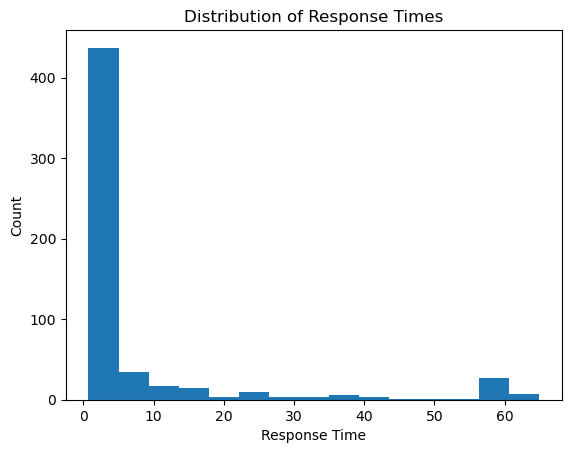

In [6]:
plt.hist(trials["response_time"], bins=15)

plt.xlabel("Response Time")
plt.ylabel("Count")
plt.title("Distribution of Response Times")
plt.show()

These visualizations help show how the behavioral labels are distributed across trials and provide context for the classification problem.

In [7]:
# Build trial x neuron population matrix
population_matrix = spikes.groupby(["trial_id", "neuron_id"]).size().unstack(fill_value=0)

# Align trials in the neural matrix with trials in the behavioral table
common_trials = population_matrix.index.intersection(trials["trial_id"])
population_matrix = population_matrix.loc[common_trials]
trials_use = trials.set_index("trial_id").loc[common_trials]

X = population_matrix.values
y = trials_use["choice"].values

print("Population matrix shape:", population_matrix.shape)
print("Aligned trial table shape:", trials_use.shape)

Population matrix shape: (569, 1557)
Aligned trial table shape: (569, 3)


The neural population matrix must be aligned with the behavioral trial table so that each row of neural activity corresponds to the correct behavioral label. This preprocessing step ensures that the decoding model is trained on correctly matched neural and behavioral observations.

choice
-1.0    304
 1.0    233
 0.0     32
Name: count, dtype: int64


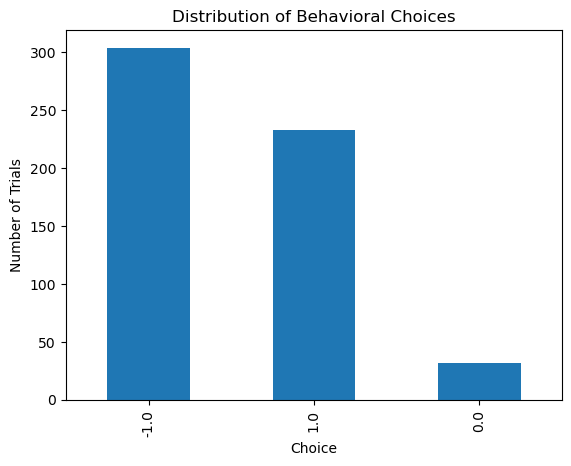

In [8]:
print(trials_use["choice"].value_counts())

trials_use["choice"].value_counts().plot(kind="bar")
plt.xlabel("Choice")
plt.ylabel("Number of Trials")
plt.title("Distribution of Behavioral Choices")
plt.show()

This plot shows whether behavioral choice labels are balanced across trials. Checking class balance is important because highly imbalanced labels can bias classification accuracy.

## 3. Dimensionality Reduction (PCA)

Neural population recordings contain activity from many neurons simultaneously, producing high-dimensional datasets. Principal Component Analysis (PCA) reduces this complexity by identifying directions of maximum variance in neural activity. Projecting neural data onto the first few principal components allows us to visualize patterns in neural population activity.

In [9]:
X = population_matrix.values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

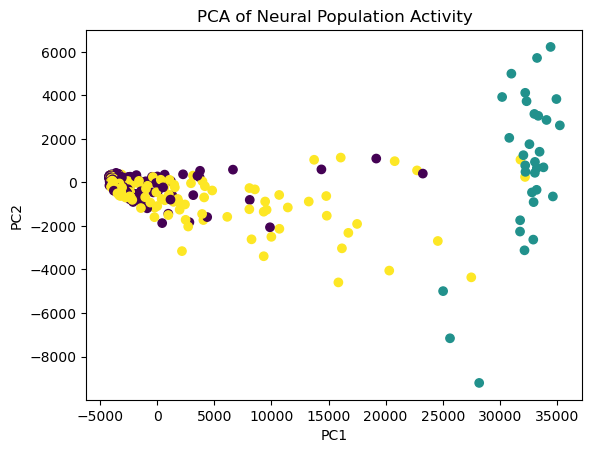

In [10]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y
            )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Neural Population Activity")
plt.show()

Each point represents neural population activity during a single trial projected onto the first two principal components. Coloring points by behavioral choice allows us to examine whether neural activity patterns differ between decisions.

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.96427532 0.01203211]
Total explained variance: 0.9763074253452507


The explained variance ratio shows how much of the neural population variability is captured by the first two principal components. This helps interpret how informative the PCA visualization is. Each point represents one trial projected into the first two principal components. Coloring by behavioral choice allows us to visually assess whether population activity differs across choices.

## 4. Neural Decoding with Logistic Regression

To test whether neural activity predicts behavioral choice, we train a logistic regression classifier. The classifier learns to associate patterns of neural firing with behavioral outcomes. Decoding accuracy measures how well neural activity predicts the animal's choice.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Decoding accuracy:", accuracy)

Decoding accuracy: 0.7134502923976608


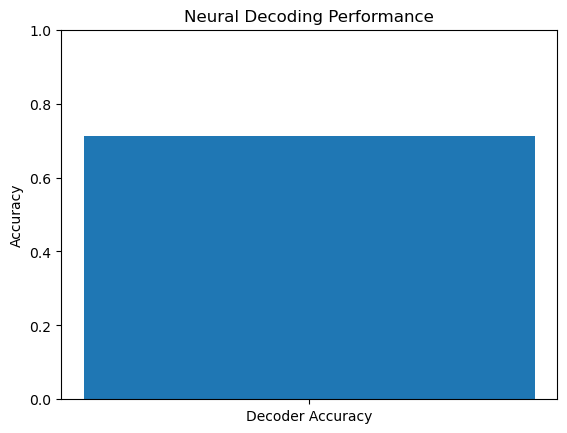

In [13]:
plt.bar(["Decoder Accuracy"], [accuracy])

plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Neural Decoding Performance")
plt.show()

Decoding accuracy above chance levels suggests that neural population activity contains information about behavioral decisions.

### Cross Validated Model Performance

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=1000)

cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

print("Cross validated accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV accuracy:", cv_scores.std())

Cross validated accuracy scores: [0.75438596 0.69298246 0.81578947 0.74561404 0.75221239]
Mean CV accuracy: 0.7521968638410185
Std CV accuracy: 0.038983309620777874


Cross validation provides a more stable estimate of decoding performance than a single train test split. Instead of evaluating the model once, the data are repeatedly split into training and testing subsets, and performance is averaged across folds.

### ROC Curve Analysis

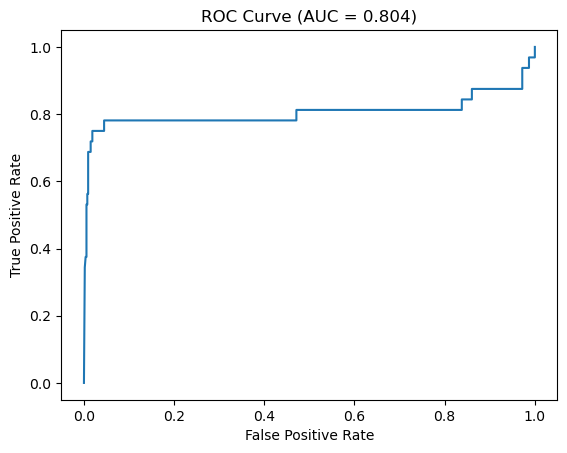

AUC: 0.8042364990689013


In [15]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score

# Convert choice to binary if needed
y_binary = (y == np.unique(y)[1]).astype(int)

y_prob = cross_val_predict(model, X, y_binary, cv=cv, method="predict_proba")[:, 1]

fpr, tpr, _ = roc_curve(y_binary, y_prob)
auc = roc_auc_score(y_binary, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.3f})")
plt.show()

print("AUC:", auc)

## 5. Permutation Test for Statistical Significance

To determine whether decoding accuracy is significantly greater than chance, we perform a permutation test. Behavioral labels are randomly shuffled across trials and decoding accuracy is recomputed multiple times. This generates a null distribution of decoding performance expected by chance.

The ROC curve evaluates classifier performance across different decision thresholds. The area under the curve (AUC) summarizes how well the model separates the two behavioral choice classes.

In [16]:
perm_acc = []

for i in range(200):
    shuffled = np.random.permutation(y)

    X_train, X_test, y_train, y_test = train_test_split(
        population_matrix, shuffled, test_size=0.3, random_state=42
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    perm_acc.append(accuracy_score(y_test, pred))

/Users/ishikanahar/ENTER/envs/COGS108_FA25/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/ishikanahar/ENTER/envs/COGS108_FA25/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://sci

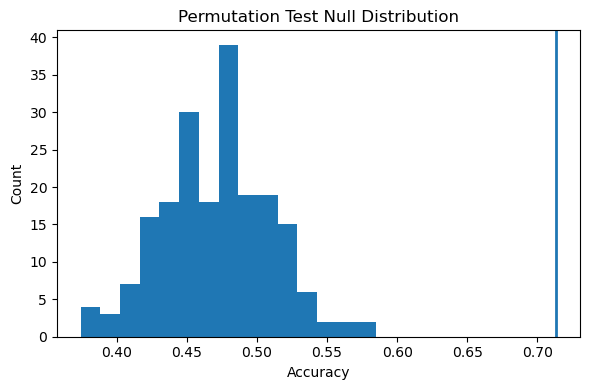

In [17]:
plt.figure(figsize=(6,4))
plt.hist(perm_acc, bins=15)
plt.axvline(accuracy, linewidth=2)
plt.xlabel("Accuracy")
plt.ylabel("Count")
plt.title("Permutation Test Null Distribution")
plt.tight_layout()
plt.show()

In [18]:
p_value = np.mean(np.array(perm_acc) >= accuracy)
print("Permutation test p-value:", p_value)
print("Observed accuracy:", accuracy)
print("Mean permuted accuracy:", np.mean(perm_acc))

Permutation test p-value: 0.0
Observed accuracy: 0.7134502923976608
Mean permuted accuracy: 0.4716081871345029


The permutation test evaluates whether observed decoding accuracy is greater than what would be expected by chance. A small permutation p value supports the conclusion that neural population activity contains real information about behavioral choice.

## Note on Anatomical Region Metadata

The current processed neuron metadata file contains placeholder anatomical labels marked as `unknown`. As a result, the notebook can still demonstrate the decoding pipeline and the integration of neural activity with behavioral trial data, but region specific interpretation is limited in the current version. In the report, this should be discussed as a limitation of the present analysis.

## 6. Summary of Results

The neural decoding pipeline shows that neural population activity contains information predictive of behavioral choice. PCA suggests that neural responses vary systematically across trials, and logistic regression achieves above chance decoding accuracy. The permutation test further supports that this performance is unlikely to arise by chance alone. Together, these results support the idea that distributed neural population activity carries information related to decision making.